In [32]:
from aeon.datasets import load_forecasting

y = load_forecasting("electricity_hourly_dataset")["series_value"].values[1]

In [38]:
from aeon.utils.windowing import sliding_windows

X = sliding_windows(y, window_size=24, stride=24)[0][
    :,
    None,
]
X

array([[[ 69.,  92.,  96., ..., 113., 104.,  99.]],

       [[ 95.,  92.,  89., ..., 119., 108., 100.]],

       [[ 95.,  91.,  88., ..., 120., 112., 100.]],

       ...,

       [[ 80.,  73.,  70., ...,  96.,  90.,  87.]],

       [[ 80.,  72.,  71., ..., 102.,  91.,  89.]],

       [[ 81.,  75.,  71., ...,  93.,  92.,  88.]]], shape=(1096, 1, 24))

In [41]:
from saxo.sklearn import SAXO

saxo = SAXO(
    timestamp_discretization="SAXO",
    n_jobs=-1,
    max_intervals=5,
    refined=True,
).fit(X)

In [43]:
ano = saxo.score_samples(X).sum(axis=-1)

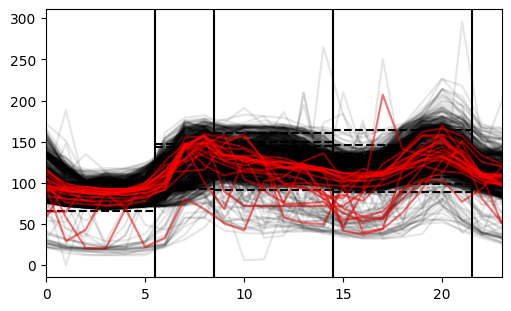

In [ ]:
from matplotlib import pyplot as plt
from saxo.viz import plot_saxo

n_ano = 20
fig, ax = plt.subplots(figsize=(5, 3), layout="constrained")
plot_saxo(saxo, [ax], X=X)
ax.plot(X[ano.argsort()[:n_ano], 0].T, color="red", alpha=10 / n_ano)
ax.set_xlim((0, X.shape[-1] - 1))
plt.show()

In [50]:
from saxo.sklearn import SAXO

tri = SAXO(
    timestamp_discretization="SAXO",
    n_jobs=-1,
    max_intervals=5,
    refined=False,
).fit(X)

In [51]:
ano_tri = tri.score_samples(X).sum(axis=-1)

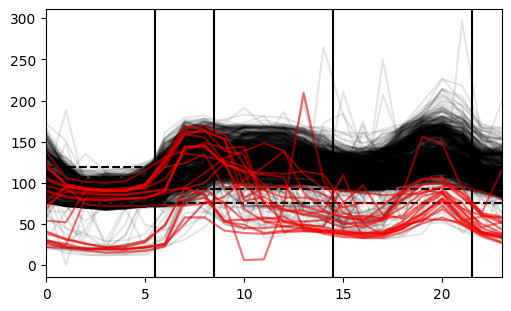

In [ ]:
from matplotlib import pyplot as plt
from saxo.viz import plot_saxo

fig, ax = plt.subplots(figsize=(5, 3), layout="constrained")
plot_saxo(tri, [ax], X=X)
ax.plot(X[ano_tri.argsort()[:n_ano], 0].T, color="red", alpha=10 / n_ano)
ax.set_xlim((0, X.shape[-1] - 1))
plt.show()